In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import CenteredNorm, LogNorm
from openpmd_viewer import OpenPMDTimeSeries

plt.rcParams["font.size"] = 14

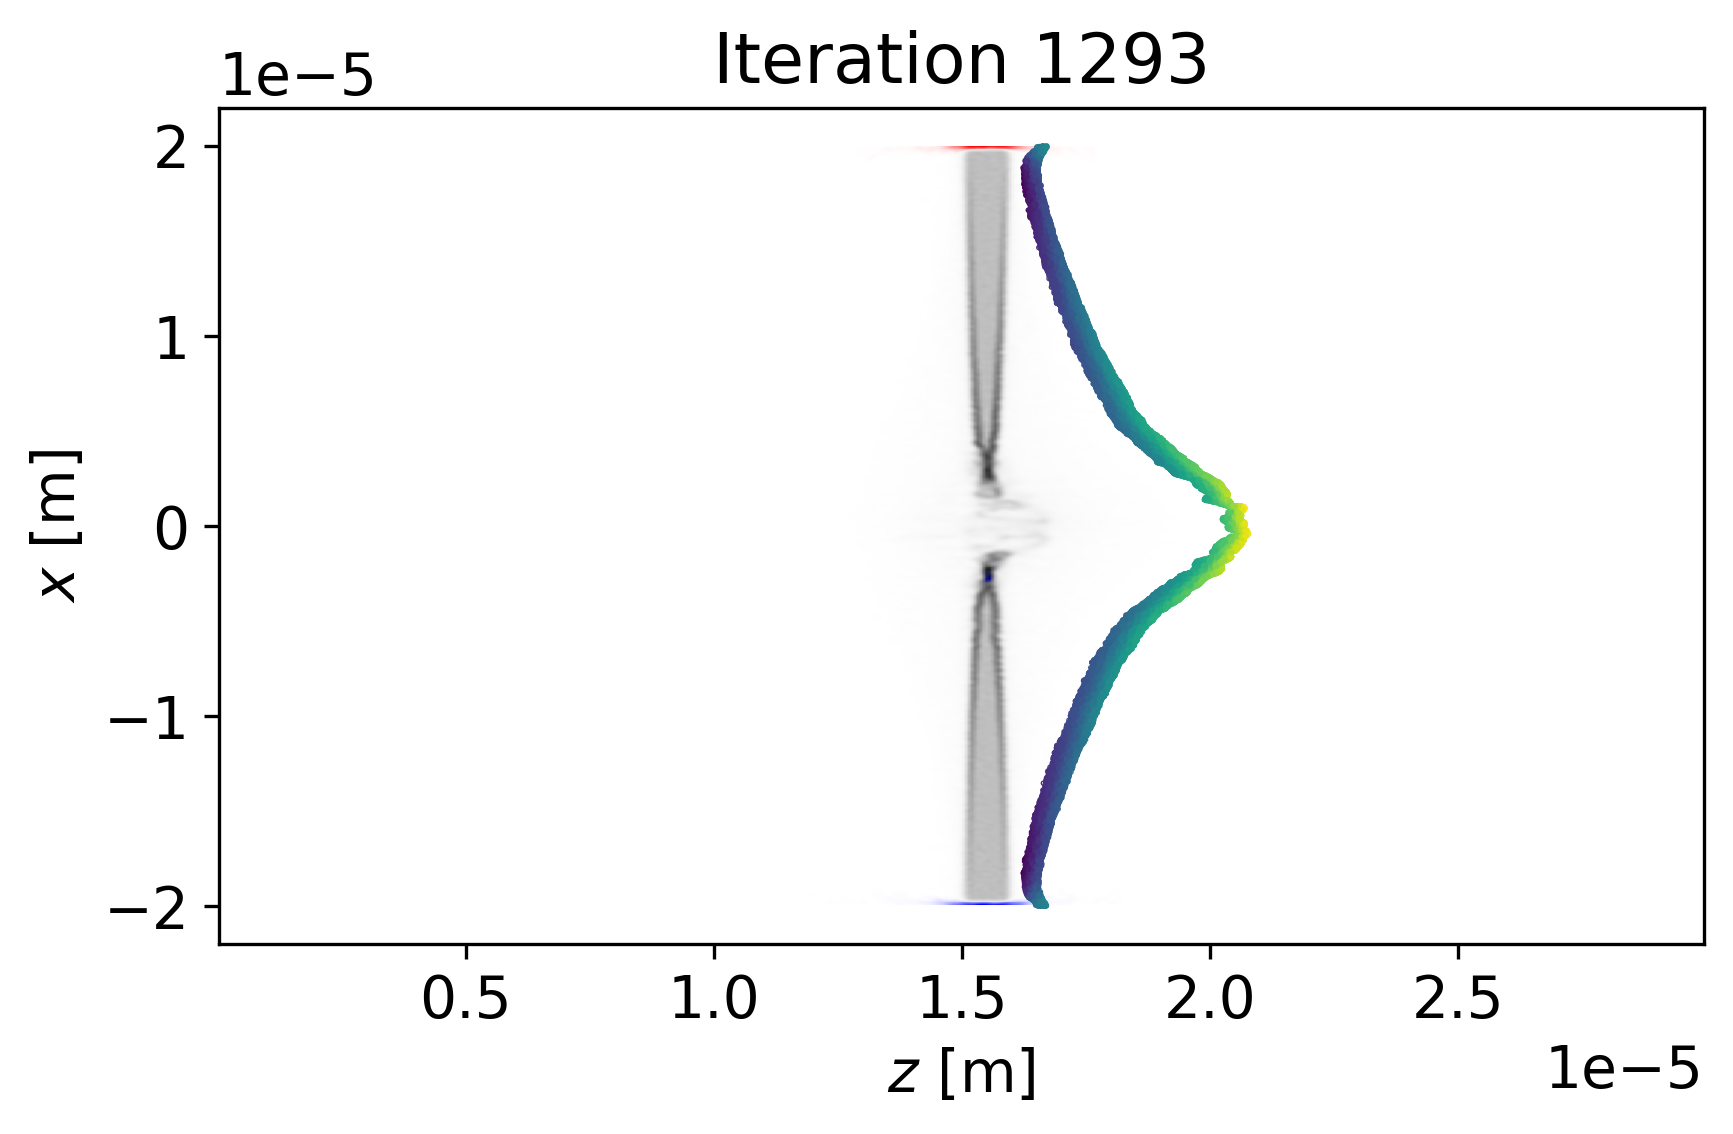

In [2]:
series = OpenPMDTimeSeries("diags/fields/")
iterations = series.iterations
seriesp = OpenPMDTimeSeries("diags/particles/")

for i in iterations[-1:]:
    fig, ax = plt.subplots(figsize=(6, 4))

    Ex, info_Ex = series.get_field(field="E", coord="x", iteration=i, plot=False)
    scale = np.max(np.abs(Ex))
    thr = 0.1 * scale
    alpha = np.zeros_like(Ex) if scale == 0 else (np.abs(Ex) - thr) / (scale - thr)
    alpha = np.clip(alpha, 0, 1)

    rhoe, info = series.get_field(field="rho_ele_targ", iteration=i)
    ext = [info.zmin, info.zmax, info.xmin, info.xmax]
    ax.imshow(-rhoe.T, aspect="auto", cmap="Greys", origin="lower", extent=ext)

    ax.imshow(
        Ex.T,
        aspect="auto",
        cmap="bwr",
        alpha=alpha.T,
        extent=ext,
        norm=CenteredNorm(vcenter=0, halfrange=0.5 * scale),
        origin="lower",
    )

    x, z, uz = seriesp.get_particle(["x", "z", "uz"], species="ion_cont", iteration=i)
    ax.scatter(z, x, c=uz, s=0.1, cmap="viridis")

    ax.set_ylabel(r"$x$ [m]")
    ax.set_xlabel(r"$z$ [m]")
    ax.set_title(f"Iteration {i}")

    fig.tight_layout()

plt.show()

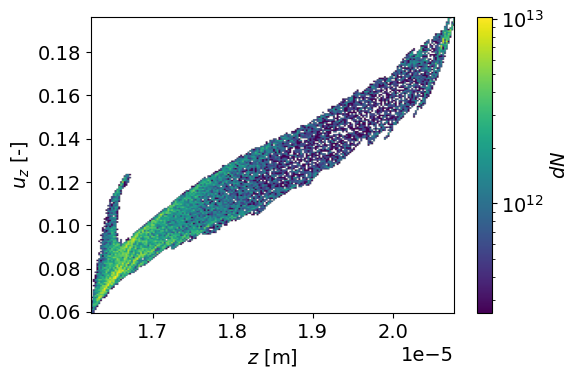

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
i = iterations[-1]
w, z, uz, x = seriesp.get_particle(
    ["w", "z", "uz", "x"], species="ion_cont", iteration=i
)

H, b1, b2 = np.histogram2d(z, uz, bins=(200, 200), weights=w)
im = ax.imshow(
    H.T,
    extent=[b1[0], b1[-1], b2[0], b2[-1]],
    aspect="auto",
    origin="lower",
    norm=LogNorm(),
)

ax.set_xlabel(r"$z$ [m]")
ax.set_ylabel(r"$u_z$ [-]")
fig.colorbar(im, ax=ax, label=r"$dN$")

fig.tight_layout()
plt.show()